In [182]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder,OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.metrics import classification_report

In [183]:
df=pd.read_csv('loan_data.csv')

In [184]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [185]:
df['person_education'].unique()

<ArrowStringArray>
['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate']
Length: 5, dtype: str

In [186]:
df['person_home_ownership'].unique()

<ArrowStringArray>
['RENT', 'OWN', 'MORTGAGE', 'OTHER']
Length: 4, dtype: str

In [187]:
df['loan_intent'].unique()

<ArrowStringArray>
[         'PERSONAL',         'EDUCATION',           'MEDICAL',
           'VENTURE',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str

In [188]:
x=df.drop(columns='loan_status')
y=df['loan_status']

In [189]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [190]:
num_col=x.select_dtypes(include='number').columns
ord_cols=['person_education']
onehot_cols=['person_gender','person_home_ownership','loan_intent','previous_loan_defaults_on_file']



([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'person_age'),
  Text(1, 0, 'person_income'),
  Text(2, 0, 'person_emp_exp'),
  Text(3, 0, 'loan_amnt'),
  Text(4, 0, 'loan_int_rate'),
  Text(5, 0, 'loan_percent_income'),
  Text(6, 0, 'cb_person_cred_hist_length'),
  Text(7, 0, 'credit_score')])

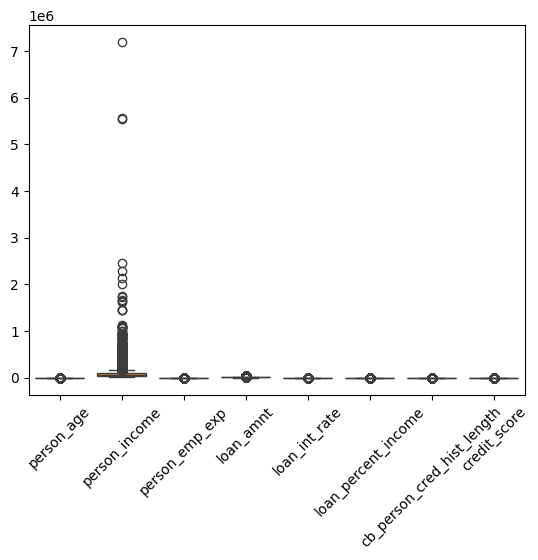

In [191]:
sns.boxplot(data=df[num_col])
plt.xticks(rotation=45)

In [192]:
df.head(2)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0


In [193]:
df['person_education'].unique()

<ArrowStringArray>
['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate']
Length: 5, dtype: str

In [194]:
ord_cols = ['person_education']

onehot_cols = [
    'person_gender',
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file'
]

preprocessing = ColumnTransformer(
    transformers=[

        (
            'ordinal',
            OrdinalEncoder(categories=[[
                'High School',
                'Associate',
                'Bachelor',
                'Master',
                'Doctorate'
            ]]),
            ord_cols
        ),

        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            onehot_cols
        )

    ],
    remainder='passthrough'
)

* 1.how to check whether the decision tree is overfit or underfit for using randomforest

In [195]:
main_pipeline = Pipeline([
    ('pre', preprocessing),
    ('model', DecisionTreeClassifier(random_state=42))
])

In [198]:
model=main_pipeline.fit(xtrain, ytrain)

In [200]:
y_train=model.predict(xtrain)

In [203]:
y_test=model.predict(xtest)

In [ ]:
print(classification_report(ytrain,y_train))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28010
           1       1.00      1.00      1.00      7990

    accuracy                           1.00     36000
   macro avg       1.00      1.00      1.00     36000
weighted avg       1.00      1.00      1.00     36000



In [204]:
print(classification_report(ytest,y_test))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94      6990
           1       0.77      0.80      0.79      2010

    accuracy                           0.90      9000
   macro avg       0.86      0.87      0.86      9000
weighted avg       0.90      0.90      0.90      9000

